In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import sys
sys.path.append('..')
from config import DATA_DIR, FIGURES_DIR


In [7]:
df = pd.read_csv(f"{DATA_DIR}/df.csv", index_col=0, parse_dates=True)
df.head()

,net_load,DA_load,actual_load,DA_solar,DA_wind,actual_solar,actual_wind,net_load_24,net_load_25,net_load_26,DA_renewable,DA_renewable_1,DA_renewable_2,DA_renewable_3,DA_load_1,DA_load_2,DA_load_3,hour_sin,hour_cos
2024-01-01 00:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,1.000000
2024-01-01 01:00:00+00:00,36625.0,51850.0,50992.0,0.0,14601.58,0.0,14367.0,NaN,NaN,NaN,14601.58,NaN,NaN,NaN,NaN,NaN,NaN,0.258819,0.965926
2024-01-01 02:00:00+00:00,34794.0,49250.0,48187.0,0.0,14179.37,0.0,13393.0,NaN,NaN,NaN,14179.37,14601.58,NaN,NaN,51850.0,NaN,NaN,0.500000,0.866025
2024-01-01 03:00:00+00:00,37872.0,47050.0,46479.0,0.0,13754.28,0.0,8607.0,NaN,NaN,NaN,13754.28,14179.37,14601.58,NaN,49250.0,51850.0,NaN,0.707107,0.707107
2024-01-01 04:00:00+00:00,38037.0,46150.0,46285.0,0.0,13076.23,0.0,8248.0,NaN,NaN,NaN,13076.23,13754.28,14179.37,14601.58,47050.0,49250.0,51850.0,0.866025,0.500000


In [8]:
# net_load=actual_load-actual_renewables ?
sum(
    df["net_load"] == df["actual_load"] - (df["actual_solar"] + df["actual_wind"])
) / len(df["net_load"] == df["actual_load"] - (df["actual_solar"] + df["actual_wind"]))

0.8507142857142858

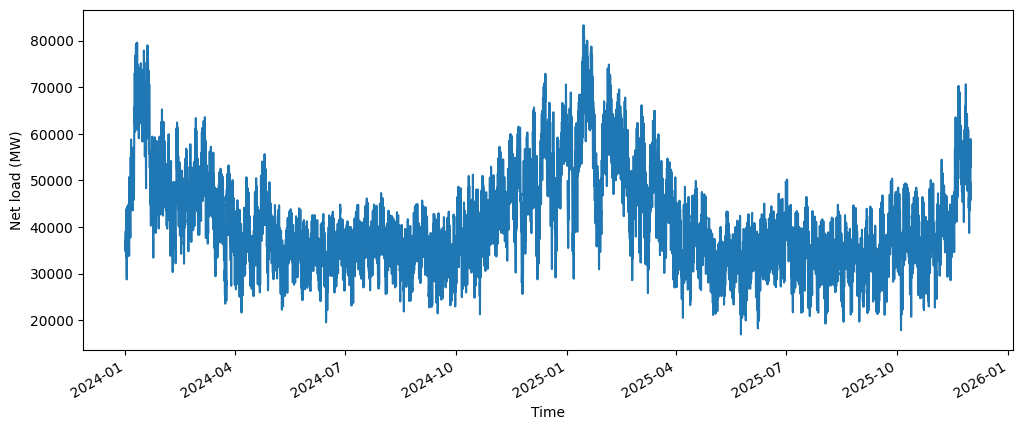

In [9]:
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(df.index, df["net_load"])
ax.set_xlabel("Time")
ax.set_ylabel("Net load (MW)")

fig.autofmt_xdate()  # rotates & spaces ticks nicely

# ✅ Save figure
plt.savefig(f"{FIGURES_DIR}/net_load.png", dpi=300, bbox_inches="tight")

plt.show()

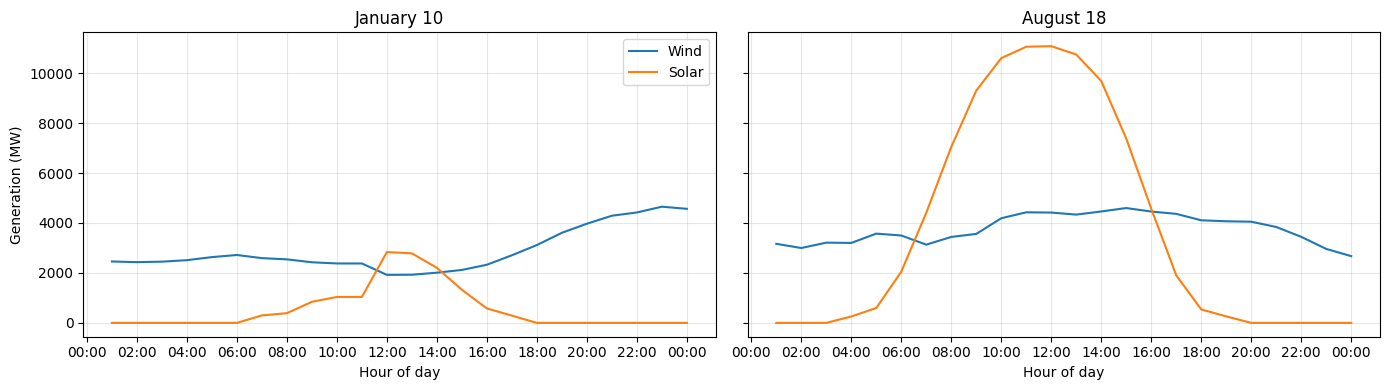

In [10]:
df_filtered_10_01 = df.iloc[217:241, :]
df_filtered_18_08 = df.iloc[5521:5545, :]

fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=True)

# ---- 10 January ----
axes[0].plot(df_filtered_10_01.index, df_filtered_10_01["actual_wind"], label="Wind")

axes[0].plot(df_filtered_10_01.index, df_filtered_10_01["actual_solar"], label="Solar")

axes[0].set_title("January 10")
axes[0].set_xlabel("Hour of day")
axes[0].set_ylabel("Generation (MW)")

axes[0].xaxis.set_major_locator(mdates.HourLocator(interval=2))
axes[0].xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
axes[0].grid(True, alpha=0.3)
axes[0].legend()


# ---- 18 August ----
axes[1].plot(df_filtered_18_08.index, df_filtered_18_08["actual_wind"], label="Wind")

axes[1].plot(df_filtered_18_08.index, df_filtered_18_08["actual_solar"], label="Solar")

axes[1].set_title("August 18")
axes[1].set_xlabel("Hour of day")

axes[1].xaxis.set_major_locator(mdates.HourLocator(interval=2))
axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
axes[1].grid(True, alpha=0.3)

plt.tight_layout()

# ✅ Save figure
plt.savefig(f"{FIGURES_DIR}/wind_solar.png", dpi=300, bbox_inches="tight")

plt.show()